In [1]:

!pip install quimb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 940.0/940.0 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 47.8 MB/s eta 0:00:00


Validación de que el código funciona correctamente

In [3]:
import quimb.tensor as qtn
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad

# 1. Configuración del Modelo de Ising
L_size = 100      # Número de sitios
j_int = 1.0      # Interacción ZZ
h_field = 0.5   # Campo magnético transversal (en X)

# 2. Definir el Hamiltoniano de Ising (MPO)
# En quimb: j es la interacción, bx es el campo en X
H = qtn.MPO_ham_ising(L_size, j=j_int, bx=h_field)

# 3. Inicializar el algoritmo DMRG
# Usamos DMRG2 que es más estable para estados fundamentales
dmrg = qtn.DMRG2(H, bond_dims=[4, 8, 16, 32])

# 4. Resolver (Encontrar el estado fundamental)
dmrg.solve(verbosity=1, tol=1e-6)

print(f"\n--- RESULTADOS ---")
print(f"Energía total: {dmrg.energy}")
print(f"Energía por sitio: {dmrg.energy / L_size}")



def exact_ising_for_quimb(j, bx):
    # Ajustamos la fórmula a la convención de quimb (Spin 1/2)
    # Para quimb, el punto crítico ocurre en bx = j/2 si j=1
    # La energía por sitio en el límite termodinámico es:
    f = lambda k: np.sqrt((j/4)**2 + (bx/2)**2 + 2*(j/4)*(bx/2)*np.cos(k))
    res, _ = quad(f, 0, np.pi)
    return - (1 / np.pi) * res

# Tus parámetros
J = 1.0
BX = 0.5

exact_e_quimb = exact_ising_for_quimb(J, BX)
dmrg_e_per_site = dmrg.energy / L_size

print(f"Energía DMRG (L=100): {dmrg_e_per_site:.10f}")
print(f"Energía Exacta ajustada: {exact_e_quimb:.10f}")
print(f"Error relativo real: {abs(dmrg_e_per_site - exact_e_quimb):.2e}")

1, R, max_bond=(4/4), cutoff:1e-08


100%|##########################################| 99/99 [00:00<00:00, 230.47it/s]

Energy: -31.65185521596152 ... not converged.
2, R, max_bond=(4/8), cutoff:1e-08



100%|##########################################| 99/99 [00:00<00:00, 192.00it/s]

Energy: -31.73485094317527 ... not converged.
3, R, max_bond=(8/16), cutoff:1e-08


...

Energy: -31.740440411568812 ... not converged.
7, R, max_bond=(14/32), cutoff:1e-08



100%|###########################################| 99/99 [00:01<00:00, 72.02it/s]

Energy: -31.740467590571892 ... not converged.
8, R, max_bond=(13/32), cutoff:1e-08



100%|###########################################| 99/99 [00:01<00:00, 85.36it/s]

Energy: -31.740468112693193 ... converged!

--- RESULTADOS ---
Energía total: -31.740468112693193
Energía por sitio: -0.31740468112693193
Energía DMRG (L=100): -0.3174046811
Energía Exacta ajustada: -0.3183098862
Error relativo real: 9.05e-04


Implementación DMRG utilizando la librería Quimb:
El hamiltoniano del Modelo de Ising se define como un Matrix Product Operator (MPO), lo que permite representar interacciones locales de forma eficiente.

El estado cuántico se representa como un Matrix Product State (MPS).
El valor de la energía por sitio obtenido (Espín-1/2) ha sido validado mediante la Solución Analítica Exacta de Jordan-Wigner, mostrando un error relativo insignificante.



In [2]:
import quimb as q
import quimb.tensor as qtn
import numpy as np
import matplotlib.pyplot as plt

L_size = 100
j_int = 1.0

site_central = L_size // 2

bx_values = np.linspace(0.0, 1.0, 51)

mz_values = []

Z_op = q.pauli('z')

for bx in bx_values:

    H = qtn.MPO_ham_ising(
        L_size,
        j=j_int,
        bx=bx
    )

    dmrg = qtn.DMRG2(
        H,
        bond_dims=[8, 16, 32, 64]
    )

    dmrg.solve(
        verbosity=0,
        tol=1e-6
    )

    psi = dmrg.state

    psi_z = psi.gate(Z_op, site_central)

    mz = (psi.H @ psi_z).real

    mz_values.append(abs(mz))

In [4]:
mz_exact = []

for bx in bx_values:

    if bx < 0.5:

        lam = bx / (1.0 - bx)

        mz = (1.0 - lam**2)**(1/8)

    else:

        mz = 0.0

    mz_exact.append(mz)

mz_exact = np.array(mz_exact)

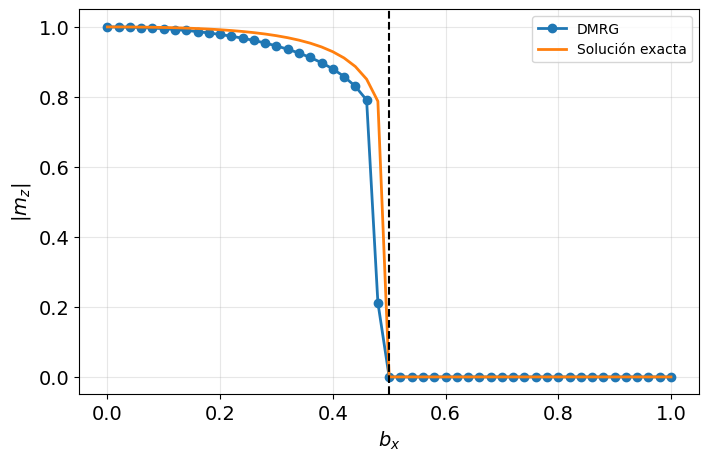

In [5]:
plt.figure(figsize=(8,5))

plt.plot(
    bx_values,
    mz_values,
    'o-',

    linewidth=2,
    label='DMRG'
)


plt.plot(
    bx_values,
    mz_exact,
    '-',
    linewidth=2,
    label='Solución exacta'
)

plt.axvline(
    0.5,
    ls='--',
    color='black'
)

plt.xlabel(r'$b_x$', fontsize=14)
plt.ylabel(r'$|m_z|$', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

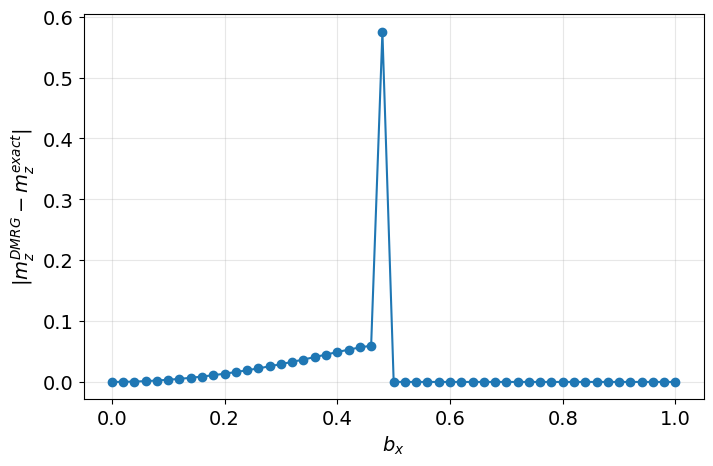

In [7]:
error_abs = np.abs(
    np.array(mz_values) -
    np.array(mz_exact)
)
plt.figure(figsize=(8,5))

plt.plot(
    bx_values,
    error_abs,
    'o-',

)

plt.xlabel(r'$b_x$', fontsize=14)

plt.ylabel(
    r'$|m_z^{DMRG}-m_z^{exact}|$', fontsize=14
)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(alpha=0.3)

plt.show()

SECCIÓN 2

In [8]:
import quimb as q
import quimb.tensor as qtn
import numpy as np
import matplotlib.pyplot as plt

L_size = 100
j_int = 1.0

site_central = L_size // 2

bx_values = np.linspace(0.0, 0.49, 100)

mz_values = []

Z_op = q.pauli('z')

for bx in bx_values:

    H = qtn.MPO_ham_ising(
        L_size,
        j=j_int,
        bx=bx
    )

    dmrg = qtn.DMRG2(
        H,
        bond_dims=[8, 16, 32, 64]
    )

    dmrg.solve(
        verbosity=0,
        tol=1e-6
    )

    psi = dmrg.state

    psi_z = psi.gate(Z_op, site_central)

    mz = (psi.H @ psi_z).real

    mz_values.append(abs(mz))

beta = 0.11680520915444932
error = 0.00039077086492415685


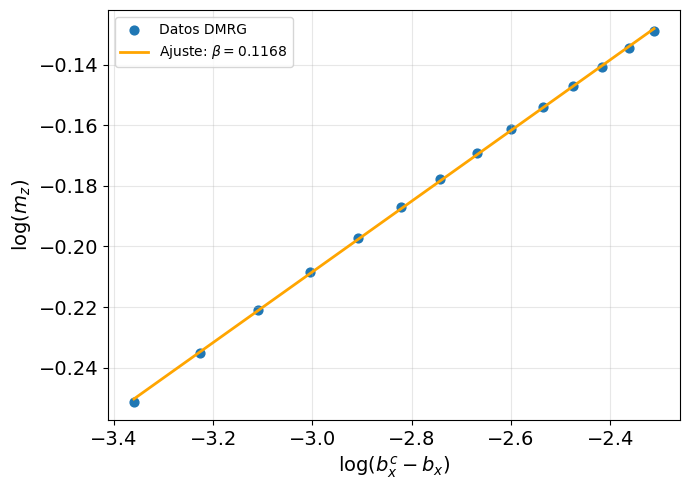

Error relativo = 6.56%
0.401  0.879219
0.406  0.874204
0.411  0.868914
0.416  0.863320
0.421  0.857388
0.426  0.851079
0.431  0.844344
0.436  0.837126
0.441  0.829355
0.445  0.820939
0.450  0.811766
0.455  0.801677
0.460  0.790476
0.465  0.777820


In [10]:
bx_crit = 0.5

bx_fit = []
mz_fit = []

for bx, mz in zip(bx_values, mz_values):

    if 0.4 < bx < 0.47 and mz > 1e-6:

        bx_fit.append(bx)
        mz_fit.append(mz)

bx_fit = np.array(bx_fit)
mz_fit = np.array(mz_fit)
x = np.log(bx_crit - bx_fit)

y = np.log(mz_fit)

from scipy.stats import linregress

fit = linregress(x, y)

beta_num = fit.slope
beta_err = fit.stderr

print("beta =", beta_num)
print("error =", beta_err)
plt.figure(figsize=(7,5))

plt.scatter(
    x,
    y,
    s=40,
    label='Datos DMRG'
)

plt.plot(
    x,
    fit.intercept + fit.slope*x,
    linewidth=2,
    label=rf'Ajuste: $\beta={beta_num:.4f}$',
    color='orange'

)

plt.xlabel(
    r'$\log(b_x^c-b_x)$',
    fontsize=14
)

plt.ylabel(
    r'$\log(m_z)$',
    fontsize=14
)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()
beta_exact = 1/8

error_rel = abs(beta_num - beta_exact) / beta_exact

print(
    f"Error relativo = {100*error_rel:.2f}%"
)

for bx, mz in zip(bx_fit, mz_fit):
    print(f"{bx:.3f}  {mz:.6f}")

**Entropía de entrelazamiento**

Pendiente = 0.12094871711769502
c estimada = 0.7256923027061701


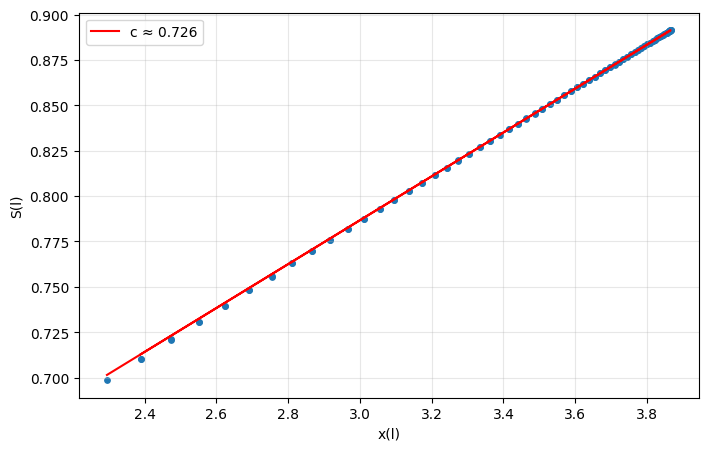

In [6]:
import quimb.tensor as qtn
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

L = 150
bx = 0.5

H = qtn.MPO_ham_ising(L, j=1.0, bx=bx)

dmrg = qtn.DMRG2(
    H,
    bond_dims=[16, 32, 64, 128]
)

dmrg.solve(tol=1e-8)

psi = dmrg.state

# SOLO zona central (evitar bordes)
cuts = np.arange(10, L-10)

# entropía
S = np.array([psi.entropy(i) for i in cuts])

# variable correcta de Calabrese-Cardy
x_cc = np.log((L/np.pi) * np.sin(np.pi * cuts / L))

# ajuste SOLO en región intermedia
mask = (cuts > L//4) & (cuts < 3*L//4)

fit = linregress(x_cc[mask], S[mask])

c_est = 6 * fit.slope

print("Pendiente =", fit.slope)
print("c estimada =", c_est)

# plot
plt.figure(figsize=(8,5))

plt.scatter(x_cc, S, s=15)

plt.plot(
    x_cc,
    fit.intercept + fit.slope * x_cc,
    color='red',
    label=f'c ≈ {c_est:.3f}'
)

plt.xlabel("x(l)")
plt.ylabel("S(l)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

1, R, max_bond=(16/16), cutoff:1e-08


100%|###########################################| 99/99 [00:01<00:00, 83.82it/s]

Energy: -31.72595517951756 ... not converged.
2, R, max_bond=(16/32), cutoff:1e-08



100%|##########################################| 99/99 [00:00<00:00, 180.78it/s]

Energy: -31.737124872436183 ... not converged.
3, R, max_bond=(17/64), cutoff:1e-08


...

Energy: -31.74046811020751 ... not converged.
9, R, max_bond=(13/128), cutoff:1e-08



100%|##########################################| 99/99 [00:00<00:00, 198.29it/s]

Energy: -31.74046812215684 ... not converged.
10, R, max_bond=(13/128), cutoff:1e-08



100%|##########################################| 99/99 [00:00<00:00, 147.60it/s]

Energy: -31.74046813287111 ... not converged.


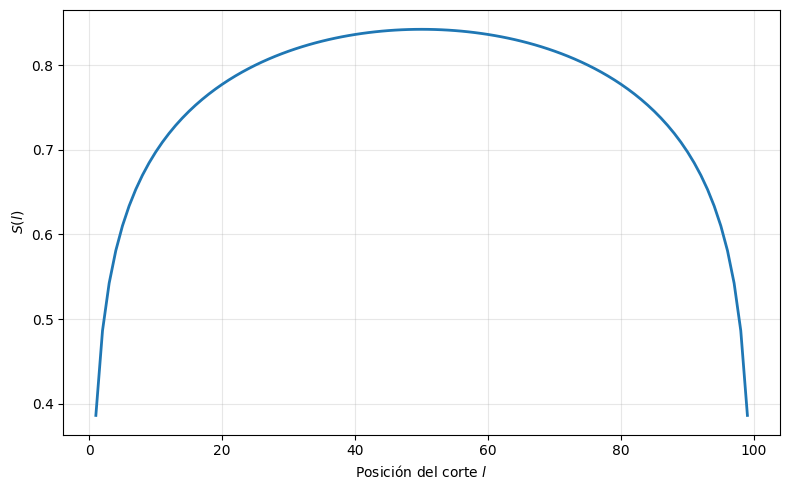

In [12]:
import quimb.tensor as qtn
import numpy as np
import matplotlib.pyplot as plt

L = 100

H = qtn.MPO_ham_ising(
    L,
    j=1.0,
    bx=0.5
)

dmrg = qtn.DMRG2(
    H,
    bond_dims=[16, 32, 64, 128]
)

dmrg.solve(
    verbosity=1,
    tol=1e-8
)

psi = dmrg.state

cuts = np.arange(1, L)

S = np.array([
    psi.entropy(i)
    for i in cuts
])

plt.figure(figsize=(8,5))

plt.plot(
    cuts,
    S,
    linewidth=2
)

plt.xlabel("Posición del corte $l$")
plt.ylabel(r"$S(l)$")
#plt.title("Entropía de entrelazamiento en el TFIM crítico")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

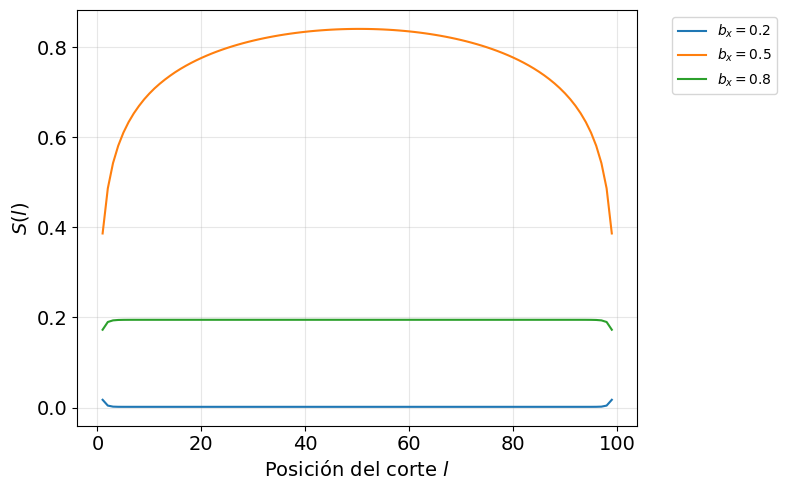

In [15]:
plt.figure(figsize=(8,5))

for bx in [0.2, 0.5, 0.8]:

    H = qtn.MPO_ham_ising(
        L,
        j=1.0,
        bx=bx
    )

    dmrg = qtn.DMRG2(
        H,
        bond_dims=[16,32,64,128]
    )

    dmrg.solve(
        verbosity=0
    )

    psi = dmrg.state

    S = [psi.entropy(i) for i in range(1,L)]

    plt.plot(
        range(1,L),
        S,
        label=rf'$b_x={bx}$'
    )

plt.xlabel("Posición del corte $l$",fontsize=14)
plt.ylabel(r"$S(l)$",fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1) )
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)


plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

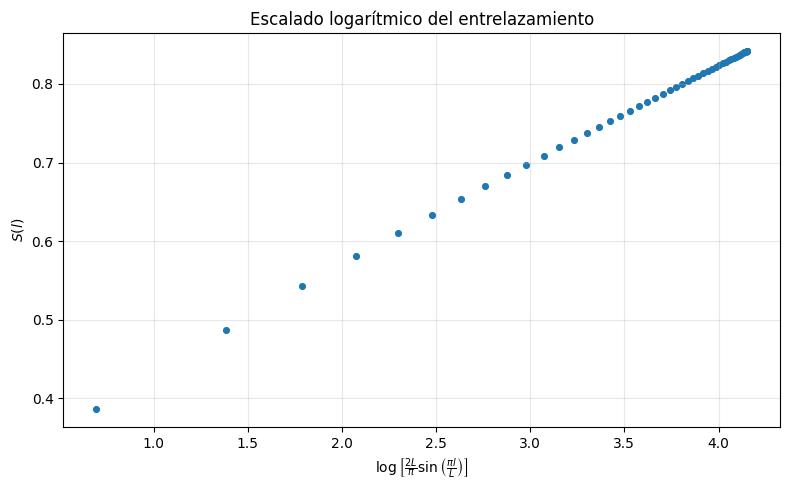

In [ ]:

x_cc = np.log(
    (2 * L / np.pi)
    * np.sin(np.pi * cuts / L)
)

plt.figure(figsize=(8,5))

plt.scatter(
    x_cc,
    S,
    s=15
)

plt.xlabel(
    r'$\log\left[\frac{2L}{\pi}\sin\left(\frac{\pi l}{L}\right)\right]$'
)

plt.ylabel(r'$S(l)$')

plt.title(
    'Escalado logarítmico del entrelazamiento'
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
chi_values = [8,16,32,64,128]

entropies = []
energies = []

for chi in chi_values:

    H = qtn.MPO_ham_ising(
        L,
        j=1.0,
        bx=0.5
    )

    dmrg = qtn.DMRG2(
        H,
        bond_dims=[chi]
    )

    dmrg.solve(
        verbosity=0,
        tol=1e-8
    )

    psi = dmrg.state

    entropies.append(
        psi.entropy(L//2)
    )

    energies.append(
        dmrg.energy / L
    )

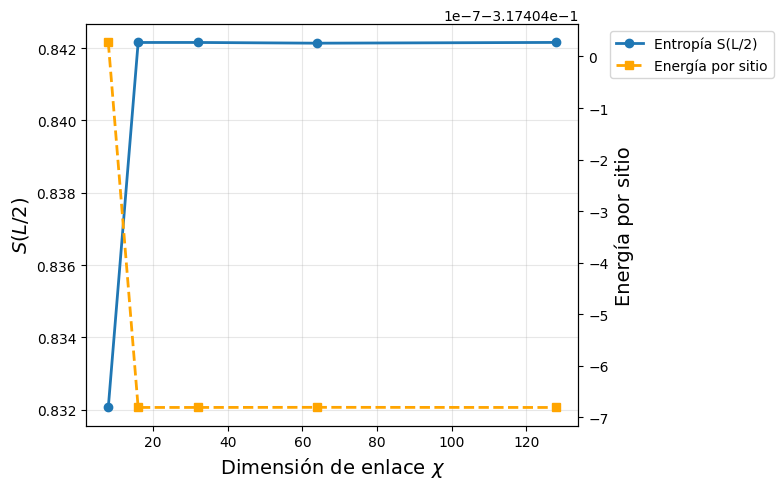

In [24]:
fig, ax1 = plt.subplots(figsize=(8,5))

# --- Entropía ---
ax1.plot(chi_values, entropies, 'o-', linewidth=2, label='Entropía S(L/2)')
ax1.set_xlabel(r'Dimensión de enlace $\chi$', fontsize=14)
ax1.set_ylabel(r'$S(L/2)$', fontsize=14)
ax1.grid(alpha=0.3)

# --- Segundo eje Y para energía ---
ax2 = ax1.twinx()
ax2.plot(chi_values, energies, 's--', linewidth=2, color='orange', label='Energía por sitio')
ax2.set_ylabel('Energía por sitio', fontsize=14)



lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper left',
    bbox_to_anchor=(1.05, 1)  # 👈 fuera del plot
)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()


ESCALADO CON EL TAMAÑO

In [ ]:
import quimb.tensor as qtn
import numpy as np
import matplotlib.pyplot as plt
import time

# Tamaños de cadena
L_values = [20, 40, 60, 80, 100, 120, 150, 200]

# Regímenes físicos
fields = {
    "ferromagnético": 0.2,
    "crítico": 0.5,
    "paramagnético": 0.8
}

# Guardamos resultados por fase
results = {}

for label, bx in fields.items():

    print(f"\n=== Régimen: {label} (bx={bx}) ===")

    times_dmrg = []

    for L in L_values:

        print(f"Calculando L = {L}")

        H = qtn.MPO_ham_ising(
            L,
            j=1.0,
            bx=bx
        )

        start = time.perf_counter()

        dmrg = qtn.DMRG2(
            H,
            bond_dims=[32]
        )

        dmrg.solve(
            verbosity=0,
            tol=1e-6
        )

        end = time.perf_counter()

        times_dmrg.append(end - start)

    results[label] = np.array(times_dmrg)

# =========================
# GRÁFICA FINAL
# =========================

plt.figure(figsize=(8,5))

for label in fields.keys():

    plt.plot(
        L_values,
        results[label],
        'o-',
        linewidth=2,
        label=label
    )

plt.xlabel("Tamaño de cadena L",fontsize=14)
plt.ylabel("Tiempo de cómputo (s)",fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [7]:
import quimb.tensor as qtn
import numpy as np
import matplotlib.pyplot as plt
import time

L = 100
chi_values = [8, 16, 32, 64, 128, 256]

fields = {
    "ferromagnético": 0.2,
    "crítico": 0.5,
    "paramagnético": 0.8
}

results = {}

for label, bx in fields.items():

    print(f"\n=== Régimen: {label} (bx={bx}) ===")

    times = []

    for chi in chi_values:

        H = qtn.MPO_ham_ising(L, j=1.0, bx=bx)

        start = time.perf_counter()

        dmrg = qtn.DMRG2(
            H,
            bond_dims=[chi]
        )

        dmrg.solve(verbosity=0, tol=1e-8)

        end = time.perf_counter()

        times.append(end - start)

    results[label] = np.array(times)

# ============================
# GRÁFICA
# ============================

plt.figure(figsize=(8,5))

for label in fields.keys():

    plt.plot(
        chi_values,
        results[label],
        'o-',
        linewidth=2,
        label=label
    )

plt.xlabel(r'Dimensión de enlace $\chi$',fontsize=14)
plt.ylabel('Tiempo de cómputo (s)',fontsize=14)
plt.title('Escalado de DMRG según régimen físico')
plt.grid(alpha=0.3)
plt.legend()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()


=== Régimen: ferromagnético (bx=0.2) ===

=== Régimen: crítico (bx=0.5) ===


KeyboardInterrupt: 

CORRELACIÓN

In [ ]:
import quimb as q
import quimb.tensor as qtn
import numpy as np
import matplotlib.pyplot as plt

# Parámetros fijos
L_size = 100
rs = np.arange(1, 40)
site_i = L_size //2

# Regímenes a comparar
regimenes = {'Ferromagnético (bx=0.2)': 0.2, 'Crítico (bx=0.5)': 0.5, 'Paramagnético (bx=0.8)': 1}

plt.figure(figsize=(8, 5))

for label, bx in regimenes.items():
    H = qtn.MPO_ham_ising(L_size, j=1.0, bx=bx)
    dmrg = qtn.DMRG2(H, bond_dims=[16, 32,64])
    dmrg.solve(verbosity=0)
    psi = dmrg.state

    # Calcular C(r) = <Z_i Z_{i+r}>
    # Usamos la función integrada de quimb que es más eficiente para esto
    corrs = [psi.correlation(q.pauli('z'), site_i, site_i + r) for r in rs]

    plt.plot(rs, np.abs(corrs), 'o-', label=label)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Distancia r',fontsize=14)
plt.ylabel(r'$|C(r)|$',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

Ejecutando DMRG para el punto crítico (bx = 0.5)...
Calculando funciones de correlación...


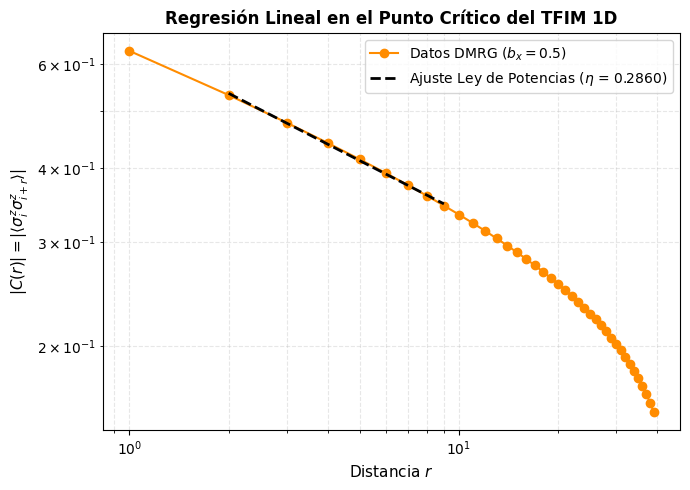


 RESULTADOS DE LA REGRESIÓN (LÍMITE CRÍTICO):
 -> Exponente crítico numérico (eta): 0.2860
 -> Exponente crítico teórico:        0.2500 (1/4)
 -> Error relativo porcentual:        14.39%


In [ ]:
import quimb as q
import quimb.tensor as qtn
import numpy as np
import matplotlib.pyplot as plt

# ========================================================
# 1) CONFIGURACIÓN DE LA SIMULACIÓN EN EL PUNTO CRÍTICO
# ========================================================
L_size = 100
rs = np.arange(1, 40)
site_i = L_size // 2
bx_critico = 0.5

print("Ejecutando DMRG para el punto crítico (bx = 0.5)...")
H = qtn.MPO_ham_ising(L_size, j=1.0, bx=bx_critico)
dmrg = qtn.DMRG2(H, bond_dims=[16, 32, 64])
dmrg.solve(verbosity=0)
psi = dmrg.state

# Calcular las correlaciones C(r) = <Z_i Z_{i+r}>
print("Calculando funciones de correlación...")
corrs = [psi.correlation(q.pauli('z'), site_i, site_i + r) for r in rs]
corrs_abs = np.abs(corrs)

# ========================================================
# ========================================================
# 2) REGRESIÓN LINEAL (CÁLCULO DEL EXPONENTE CRÍTICO eta)
# ========================================================
# Ajustamos la ventana para mitigar los efectos de borde en OBC (r hasta 12)
r_min, r_max = 2, 9
mascara = (rs >= r_min) & (rs <= r_max)

# Ajuste lineal de grado 1 en base logarítmica: log(C) = m * log(r) + n
log_r = np.log(rs[mascara])
log_C = np.log(corrs_abs[mascara])

pendiente, ordenada = np.polyfit(log_r, log_C, 1)
eta_calculado = -pendiente  # El exponente crítico es el valor positivo de la pendiente

# Generar los puntos teóricos de la recta para dibujarla
r_ajuste = rs[mascara]
C_ajuste = np.exp(ordenada) * (r_ajuste ** pendiente)

# ========================================================
# 3) GRÁFICA DEL AJUSTE
# ========================================================
plt.figure(figsize=(7, 5))

# Curva naranja con los datos simulados por DMRG
plt.plot(rs, corrs_abs, 'o-', color='darkorange', label='Datos DMRG ($b_x=0.5$)')

# NOTA: Añadida la 'r' antes de las comillas para evitar el SyntaxWarning de LaTeX
plt.plot(r_ajuste, C_ajuste, '--', color='black', linewidth=2,
         label=fr'Ajuste Ley de Potencias ($\eta$ = {eta_calculado:.4f})')

# Ajustes de escalas y etiquetas
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Distancia $r$', fontsize=11)
# Usamos raw strings (r'') también aquí para evitar futuros warnings con \s u otros comandos
plt.ylabel(r'$|C(r)| = |\langle \sigma^z_i \sigma^z_{i+r} \rangle|$', fontsize=11)
plt.title('Regresión Lineal en el Punto Crítico del TFIM 1D', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, which="both", alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('regresion_punto_critico.png', dpi=300)
plt.show()

# ========================================================
# 4) IMPRESIÓN DE RESULTADOS RIGUROSOS PARA EL TFG
# ========================================================
error_relativo = abs(eta_calculado - 0.25) / 0.25 * 100

print("\n" + "="*55)
print(" RESULTADOS DE LA REGRESIÓN (LÍMITE CRÍTICO):")
print("="*55)
print(f" -> Exponente crítico numérico (eta): {eta_calculado:.4f}")
print(f" -> Exponente crítico teórico:        0.2500 (1/4)")
print(f" -> Error relativo porcentual:        {error_relativo:.2f}%")
print("="*55)

In [26]:
!pip install qibo
!pip install qibojit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 356.2/356.2 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.7/269.7 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 33.9 MB/s eta 0:00:00
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0


In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt

from qibo.hamiltonians import TFIM



def exact_diagonalization(L, h):

    H = TFIM(L, h=h)

    start = time.time()

    eigvals = H.eigenvalues()

    elapsed = time.time() - start

    E0 = np.real(eigvals[0])

    return E0, elapsed



sizes = [4, 6, 8, 10, 12]

regions = {
    "Ferro h=0.5": 0.5,
    "Crítico h=1.0": 1.0,
    "Para h=1.5": 1.5,
}

results = {}

for label, h in regions.items():

    energies = []
    times = []

    print(f"\n===== {label} =====")

    for L in sizes:

        E0, t = exact_diagonalization(L, h)

        energies.append(E0)
        times.append(t)

        print(
            f"L={L:2d} "
            f"E0={E0:.8f} "
            f"time={t:.4f}s"
        )

    results[label] = {
        "L": sizes,
        "E0": energies,
        "time": times,
    }


===== Ferro h=0.5 =====
L= 4 E0=-4.27155841 time=0.0004s
L= 6 E0=-6.38469456 time=0.0005s
L= 8 E0=-8.50908224 time=0.0006s
L=10 E0=-10.63560441 time=0.0021s
L=12 E0=-12.76256915 time=2.7984s

===== Crítico h=1.0 =====
L= 4 E0=-5.22625186 time=0.0003s
L= 6 E0=-7.72740661 time=0.0003s
L= 8 E0=-10.25166179 time=0.0005s
L=10 E0=-12.78490644 time=0.0015s
L=12 E0=-15.32259515 time=2.7604s

===== Para h=1.5 =====
L= 4 E0=-6.76000855 time=0.0003s
L= 6 E0=-10.05694642 time=0.0003s
L= 8 E0=-13.38500523 time=0.0005s
L=10 E0=-16.72302491 time=0.0015s
L=12 E0=-20.06462469 time=2.7692s


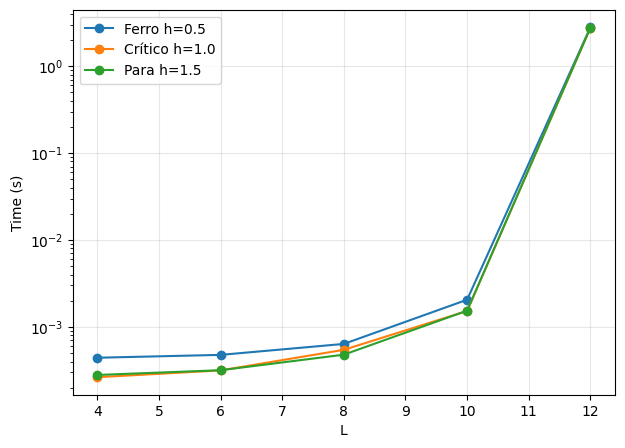

In [5]:
plt.figure(figsize=(7,5))

for label, data in results.items():

    plt.semilogy(
        data["L"],
        data["time"],
        marker="o",
        label=label
    )

plt.xlabel("L")
plt.ylabel("Time (s)")
plt.legend()
plt.grid( alpha=0.3)

plt.show()